## 1. Why CNN?
* Definition: A specialized deep learning architecture designed for grid-like spatial data (such as images) that preserves pixel neighborhood relationships.
* Use Cases:
    * Computer vision tasks, image classification, and object detection.
* Pros:
    * Drastically reduces parameter count compared to fully connected networks via parameter sharing and local connectivity.
* Cons:
    * Computationally heavy; less effective on non-grid or unstructured data.

## 2. Local Receptive Field
* Definition: The restricted region of the input volume that a particular neuron in a convolutional layer examines.
* Use Cases:
    * Extracting localized spatial features like edges, corners, and textures.
* Pros:
    * Captures local spatial dependencies efficiently without processing the entire image at once.
* Cons:
    * Requires stacking multiple layers to build a global, holistic understanding of the image.

### Visualizing Local Receptive Field

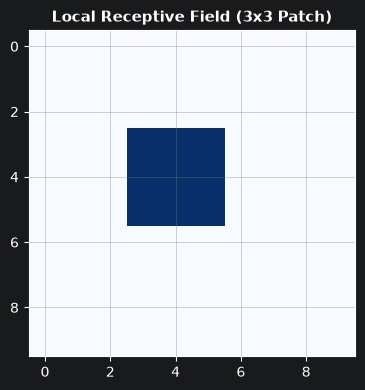

In [2]:
import numpy as np
import matplotlib.pyplot as plt

grid = np.zeros((10, 10))
grid[3:6, 3:6] = 1.0 # Receptive field patch

plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap='Blues', interpolation='nearest')
plt.title("Local Receptive Field (3x3 Patch)", fontsize=11, fontweight='bold')
plt.grid(True, color='gray', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## 3. Shared Weights
* Definition: The exact same kernel weight parameters are applied across all spatial locations of the input image.
* Use Cases:
    * Extracting features invariant to spatial position (translation invariance).
* Pros:
    * Massively reduces total model parameters and prevents overfitting.
* Cons:
    * Restricts the network to learn translation-invariant features exclusively.

## 4. Convolution
* Definition: The mathematical operation of element-wise multiplying a kernel over an input matrix and summing the results.
* Use Cases:
    * Feature extraction in convolutional neural network layers.
* Pros:
    * Efficiently extracts spatial hierarchies and structural patterns.
* Cons:
    * Causes boundary information loss unless spatial padding is applied.

### Visualizing Convolution Operation Flow

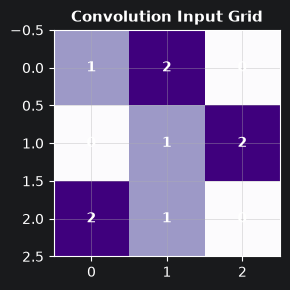

In [4]:
import numpy as np
import matplotlib.pyplot as plt

input_matrix = np.array([[1, 2, 0], [0, 1, 2], [2, 1, 0]])

plt.figure(figsize=(4, 3))
plt.imshow(input_matrix, cmap='Purples', interpolation='nearest')
plt.title("Convolution Input Grid", fontsize=11, fontweight='bold')
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(input_matrix[i, j]), ha='center', va='center', fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Kernel
* Definition: A small matrix of weights used to perform the convolution operation.
* Use Cases:
    * Detecting specific patterns like vertical edges, horizontal lines, or curves.
* Pros:
    * Compact representation for local pattern matching.
* Cons:
    * Fixed size per layer, limiting multi-scale pattern capture simultaneously.

### Visualizing Kernel Matrix

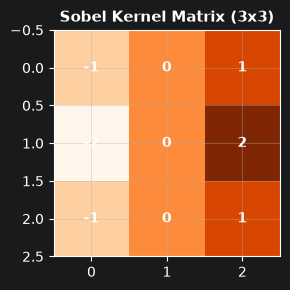

In [5]:
import numpy as np
import matplotlib.pyplot as plt

kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])

plt.figure(figsize=(4, 3))
plt.imshow(kernel, cmap='Oranges', interpolation='nearest')
plt.title("Sobel Kernel Matrix (3x3)", fontsize=11, fontweight='bold')
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(kernel[i, j]), ha='center', va='center', fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Filter
* Definition: A collection of 2D kernels (one for each input channel) that output a single 2D feature map.
* Use Cases:
    * Extracting multiple distinct feature representations from multi-channel input data (e.g., RGB).
* Pros:
    * Allows learning diverse feature extractors concurrently across channels.
* Cons:
    * Increases channel dimension and computational memory consumption.

## 7. Feature Map
* Definition: The output tensor resulting from the convolution of a filter over an input volume.
* Use Cases:
    * Representing detected patterns and features across spatial coordinates.
* Pros:
    * Highlights exact spatial locations of learned features.
* Cons:
    * Lower spatial resolution as depth increases in deep layers.

### Visualizing Feature Map Heatmap

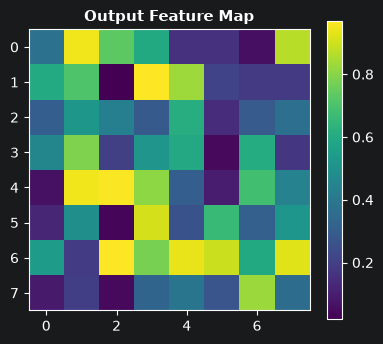

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
feature_map = np.random.rand(8, 8)

plt.figure(figsize=(4, 3.5))
plt.imshow(feature_map, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.title("Output Feature Map", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Padding
* Definition: Adding extra border pixels (usually zeros) around the input matrix.
* Use Cases:
    * Preserving spatial dimensions and preventing border information loss.
* Pros:
    * Keeps output feature map size consistent with input size across layers.
* Cons:
    * Introduces boundary zero-padding artifacts if padded incorrectly.

### Visualizing Padded Matrix

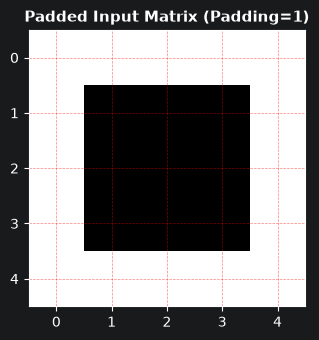

In [8]:
import numpy as np
import matplotlib.pyplot as plt

padded_matrix = np.zeros((5, 5))
padded_matrix[1:4, 1:4] = 1.0

plt.figure(figsize=(4, 3.5))
plt.imshow(padded_matrix, cmap='Greys', interpolation='nearest')
plt.title("Padded Input Matrix (Padding=1)", fontsize=11, fontweight='bold')
plt.grid(True, color='red', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

## 9. Stride
* Definition: The step size at which the kernel slides across the input matrix.
* Use Cases:
    * Controlling feature map spatial resolution downsampling.
* Pros:
    * Reduces computational complexity and spatial dimensions without requiring separate pooling layers.
* Cons:
    * Can discard fine-grained spatial details if stride is set too large.

## 10. Dilation
* Definition: Inserting spaces (holes) between kernel elements to expand the receptive field without adding parameters.
* Use Cases:
    * Semantic segmentation and capturing multi-scale context.
* Pros:
    * Exponentially enlarges the receptive field with minimal parameter cost.
* Cons:
    * Can cause "gridding effects" or loss of fine local continuity.

### Visualizing Dilated Kernel Grid

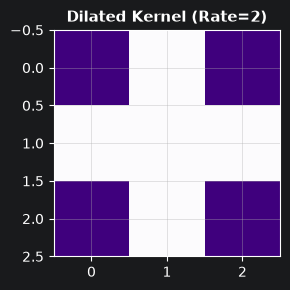

In [10]:
import numpy as np
import matplotlib.pyplot as plt

dilated = np.array([[1, 0, 1], [0, 0, 0], [1, 0, 1]])

plt.figure(figsize=(4, 3))
plt.imshow(dilated, cmap='Purples', interpolation='nearest')
plt.title("Dilated Kernel (Rate=2)", fontsize=11, fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

## 11. Pooling
* Definition: A downsampling operation (Max or Average) that reduces spatial dimensions of feature maps.
* Use Cases:
    * Summarizing features and ensuring translation invariance.
* Pros:
    * Reduces computation overhead and controls overfitting.
* Cons:
    * Destroys exact spatial coordinates and positional precision.

## 12. Flatten
* Definition: Reshaping a multi-dimensional tensor (e.g., 3D feature maps) into a 1D vector.
* Use Cases:
    * Bridging convolutional feature extraction layers to fully connected classification layers.
* Pros:
    * Standardizes tensor shapes for dense linear layers.
* Cons:
    * Completely discards remaining spatial arrangement structures.

## 13. Fully Connected Layer (Dense)
* Definition: A layer where every neuron is connected to every activation in the previous layer.
* Use Cases:
    * Final classification or regression based on extracted CNN features.
* Pros:
    * Combines global features for final decision making.
* Cons:
    * Massive parameter count, highly prone to overfitting.

## 14. CNN Architecture
* Definition: The sequential layering of convolutional blocks, pooling layers, and fully connected classification layers.
* Use Cases:
    * End-to-end computer vision pipelines (e.g., LeNet, VGG, ResNet).
* Pros:
    * Highly optimized, modular design for visual recognition tasks.
* Cons:
    * Complex architectural tuning required for optimal depth and width.